In [14]:
# Week 1-2: Data Cleaning & EDA
# AnalystLab Africa Internship

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("✅ Libraries reloaded!")

✅ Libraries reloaded!


In [7]:
import pandas as pd

# Load Titanic
titanic = pd.read_csv(r'C:\Users\THEMBINKOSI\Desktop\AnalystLab_Internship\Titanic-Dataset.csv')

# Load Housing
housing = pd.read_csv(r'C:\Users\THEMBINKOSI\Desktop\AnalystLab_Internship\Housing.csv')

print(f"✅ Titanic loaded: {titanic.shape}")
print(f"✅ Housing loaded: {housing.shape}")

✅ Titanic loaded: (891, 12)
✅ Housing loaded: (545, 13)


In [8]:
# Titanic - first 5 rows
print("=" * 50)
print("TITANIC DATASET - First 5 Rows")
print("=" * 50)
display(titanic.head())

print("\n")

# Housing - first 5 rows
print("=" * 50)
print("HOUSING DATASET - First 5 Rows")
print("=" * 50)
display(housing.head())

TITANIC DATASET - First 5 Rows


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S




HOUSING DATASET - First 5 Rows


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [9]:
 # Titanic info
print("=" * 50)
print("TITANIC - DATA INFO")
print("=" * 50)
titanic.info()

print("\n" + "=" * 50)
print("TITANIC - MISSING VALUES")
print("=" * 50)
print(titanic.isnull().sum())

TITANIC - DATA INFO
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB

TITANIC - MISSING VALUES
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Emba

In [10]:
# Housing info
print("=" * 50)
print("HOUSING - DATA INFO")
print("=" * 50)
housing.info()

print("\n" + "=" * 50)
print("HOUSING - MISSING VALUES")
print("=" * 50)
print(housing.isnull().sum())

HOUSING - DATA INFO
<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB

HOUSING - MISSING VALUES
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestr

In [11]:
# Create a clean copy
titanic_clean = titanic.copy()

# Fill Age with median
titanic_clean['Age'] = titanic_clean['Age'].fillna(titanic_clean['Age'].median())

# Fill Embarked with mode (most common value)
titanic_clean['Embarked'] = titanic_clean['Embarked'].fillna(titanic_clean['Embarked'].mode()[0])

# Drop Cabin column (687 out of 891 missing - too many to fill)
titanic_clean = titanic_clean.drop('Cabin', axis=1)

# Drop duplicates if any
titanic_clean = titanic_clean.drop_duplicates()

print(" Titanic cleaned!")
print(f"New shape: {titanic_clean.shape}")
print(f"Missing values remaining:\n{titanic_clean.isnull().sum()}")

✅ Titanic cleaned!
New shape: (891, 11)
Missing values remaining:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [12]:
print("TITANIC - Any missing values?", titanic_clean.isnull().sum().sum())
print("HOUSING - Any missing values?", housing.isnull().sum().sum())

print("\n Both datasets are clean and ready for EDA!")

TITANIC - Any missing values? 0
HOUSING - Any missing values? 0

 Both datasets are clean and ready for EDA!


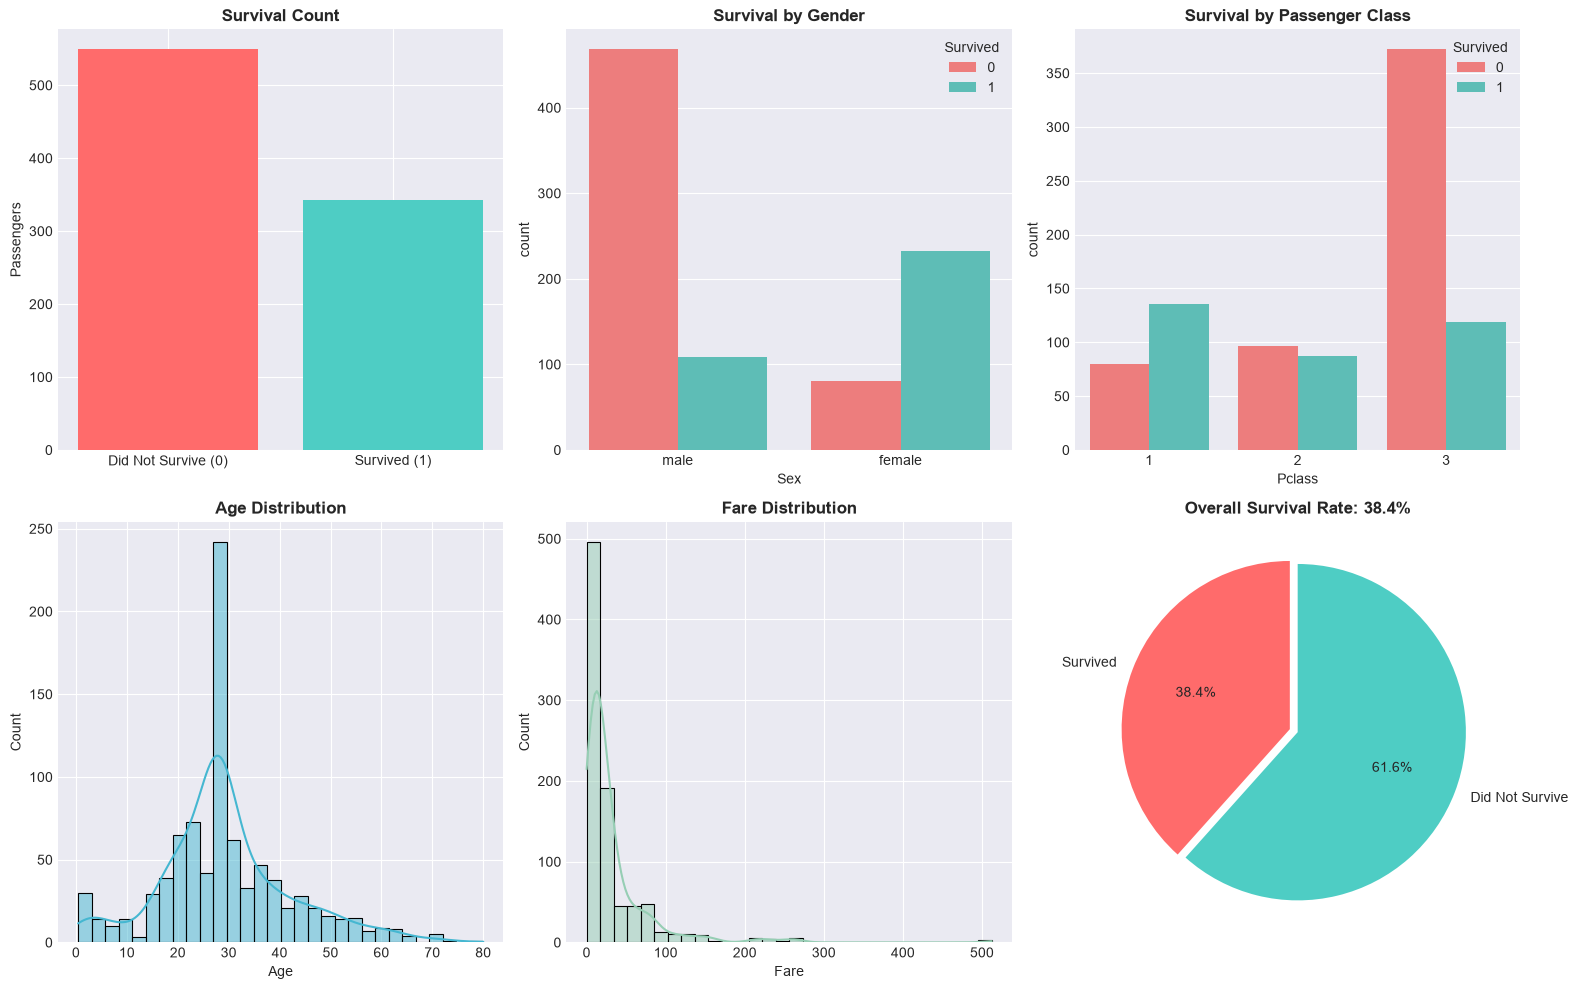

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Survival Count
colors = ['#FF6B6B', '#4ECDC4']
surv_counts = titanic_clean['Survived'].value_counts()
axes[0,0].bar(['Did Not Survive (0)', 'Survived (1)'], surv_counts.values, color=colors)
axes[0,0].set_title('Survival Count', fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('Passengers')

# 2. Survival by Sex
sns.countplot(data=titanic_clean, x='Sex', hue='Survived', palette=colors, ax=axes[0,1])
axes[0,1].set_title('Survival by Gender', fontsize=12, fontweight='bold')

# 3. Survival by Passenger Class
sns.countplot(data=titanic_clean, x='Pclass', hue='Survived', palette=colors, ax=axes[0,2])
axes[0,2].set_title('Survival by Passenger Class', fontsize=12, fontweight='bold')

# 4. Age Distribution
sns.histplot(data=titanic_clean, x='Age', bins=30, kde=True, color='#45B7D1', ax=axes[1,0])
axes[1,0].set_title('Age Distribution', fontsize=12, fontweight='bold')

# 5. Fare Distribution
sns.histplot(data=titanic_clean, x='Fare', bins=30, kde=True, color='#96CEB4', ax=axes[1,1])
axes[1,1].set_title('Fare Distribution', fontsize=12, fontweight='bold')

# 6. Survival Rate %
surv_rate = titanic_clean['Survived'].mean() * 100
axes[1,2].pie([surv_rate, 100-surv_rate], labels=['Survived', 'Did Not Survive'], 
              colors=colors, autopct='%1.1f%%', startangle=90, explode=(0.05, 0))
axes[1,2].set_title(f'Overall Survival Rate: {surv_rate:.1f}%', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

C:\Users\THEMBINKOSI\AppData\Local\Temp\ipykernel_30636\3038285151.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=housing, x='bedrooms', palette='Set2', ax=axes[0,2])
C:\Users\THEMBINKOSI\AppData\Local\Temp\ipykernel_30636\3038285151.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=housing, x='furnishingstatus', y='price', palette='Set2', ax=axes[1,0])
C:\Users\THEMBINKOSI\AppData\Local\Temp\ipykernel_30636\3038285151.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=housing, x='airconditioning', y='price', pale

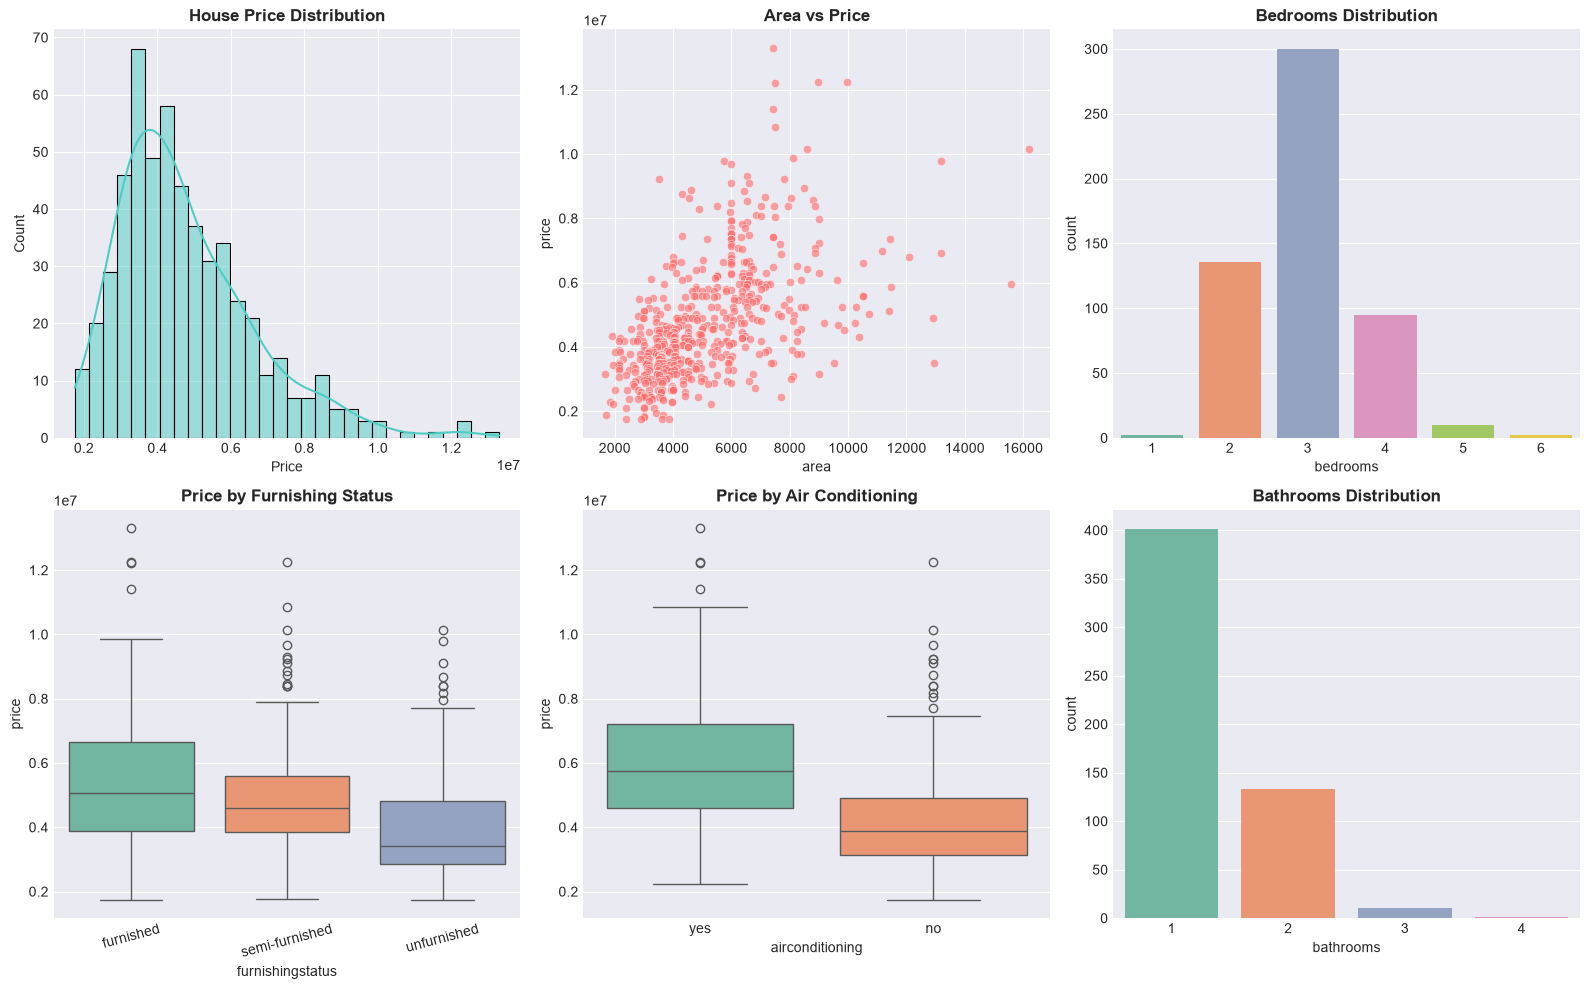

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Price Distribution
sns.histplot(data=housing, x='price', bins=30, kde=True, color='#4ECDC4', ax=axes[0,0])
axes[0,0].set_title('House Price Distribution', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Price')

# 2. Area vs Price
sns.scatterplot(data=housing, x='area', y='price', color='#FF6B6B', alpha=0.6, ax=axes[0,1])
axes[0,1].set_title('Area vs Price', fontsize=12, fontweight='bold')

# 3. Bedrooms Count
sns.countplot(data=housing, x='bedrooms', palette='Set2', ax=axes[0,2])
axes[0,2].set_title('Bedrooms Distribution', fontsize=12, fontweight='bold')

# 4. Furnishing Status vs Price
sns.boxplot(data=housing, x='furnishingstatus', y='price', palette='Set2', ax=axes[1,0])
axes[1,0].set_title('Price by Furnishing Status', fontsize=12, fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=15)

# 5. Air Conditioning vs Price
sns.boxplot(data=housing, x='airconditioning', y='price', palette='Set2', ax=axes[1,1])
axes[1,1].set_title('Price by Air Conditioning', fontsize=12, fontweight='bold')

# 6. Bathrooms Distribution
sns.countplot(data=housing, x='bathrooms', palette='Set2', ax=axes[1,2])
axes[1,2].set_title('Bathrooms Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

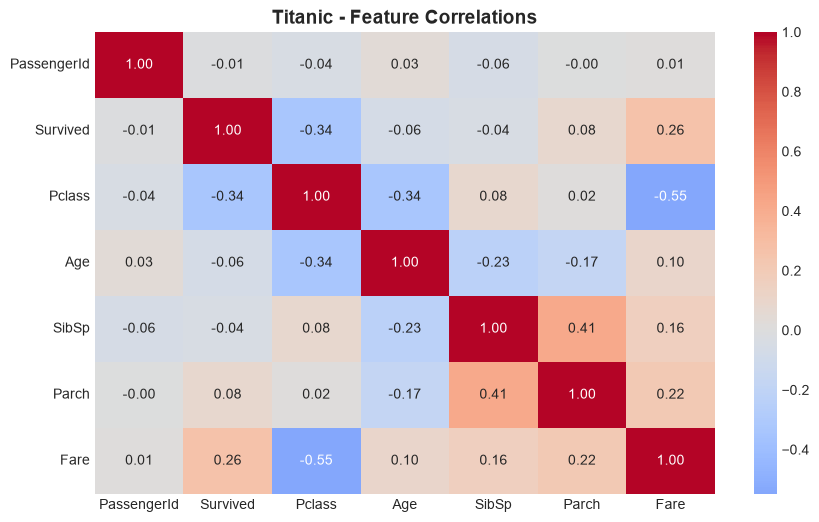

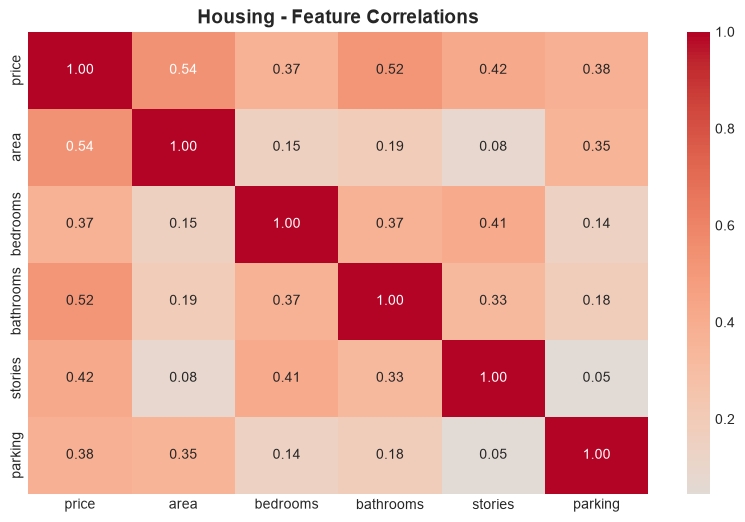

In [17]:
# Titanic Correlation
plt.figure(figsize=(10, 6))
numeric_titanic = titanic_clean.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_titanic.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Titanic - Feature Correlations', fontsize=14, fontweight='bold')
plt.show()

print("\n")

# Housing Correlation
plt.figure(figsize=(10, 6))
numeric_housing = housing.select_dtypes(include=['int64'])
sns.heatmap(numeric_housing.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Housing - Feature Correlations', fontsize=14, fontweight='bold')
plt.show()

In [18]:
# Titanic - Top correlations with Survival
print("=" * 50)
print("TITANIC - CORRELATIONS WITH SURVIVAL")
print("=" * 50)
titanic_corr = numeric_titanic.corr()['Survived'].sort_values(ascending=False)
print(titanic_corr)

print("\n" + "=" * 50)
print("HOUSING - CORRELATIONS WITH PRICE")
print("=" * 50)
housing_corr = numeric_housing.corr()['price'].sort_values(ascending=False)
print(housing_corr)

TITANIC - CORRELATIONS WITH SURVIVAL
Survived       1.000000
Fare           0.257307
Parch          0.081629
PassengerId   -0.005007
SibSp         -0.035322
Age           -0.064910
Pclass        -0.338481
Name: Survived, dtype: float64

HOUSING - CORRELATIONS WITH PRICE
price        1.000000
area         0.535997
bathrooms    0.517545
stories      0.420712
parking      0.384394
bedrooms     0.366494
Name: price, dtype: float64


In [20]:
print("""
╔══════════════════════════════════════════════════╗
║         WEEK 1-2: KEY INSIGHTS SUMMARY           ║
╠══════════════════════════════════════════════════╣
║                                                  ║
║  TITANIC INSIGHTS:                               ║
║  • Survival rate: 38.4% (only 342 of 891 survived)║
║  • Gender impact: Women survived at a much       ║
║    higher rate than men                          ║
║  • Class impact: 1st class had highest survival; ║
║    3rd class had the lowest                      ║
║  • Age pattern: Most passengers were 20-40 years ║
║    old; children had higher survival rates        ║
║  • Top predictor of survival: Pclass (-0.34)     ║
║    followed by Fare (0.26)                       ║
║                                                  ║
║  HOUSING INSIGHTS:                               ║
║  • Price range: 1.3M to 13.3M                    ║
║  • Biggest price factor: Area (0.54 correlation) ║
║  • Furnishing effect: Furnished houses tend to   ║
║    have higher prices                            ║
║  • Air conditioning effect: Houses with AC are   ║
║    priced higher than those without              ║
║  • Top predictor of price: Area, followed by     ║
║    bathrooms (0.52) and stories (0.42)           ║
║                                                  ║
╚══════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════╗
║         WEEK 1-2: KEY INSIGHTS SUMMARY           ║
╠══════════════════════════════════════════════════╣
║                                                  ║
║  TITANIC INSIGHTS:                               ║
║  • Survival rate: 38.4% (only 342 of 891 survived)║
║  • Gender impact: Women survived at a much       ║
║    higher rate than men                          ║
║  • Class impact: 1st class had highest survival; ║
║    3rd class had the lowest                      ║
║  • Age pattern: Most passengers were 20-40 years ║
║    old; children had higher survival rates        ║
║  • Top predictor of survival: Pclass (-0.34)     ║
║    followed by Fare (0.26)                       ║
║                                                  ║
║  HOUSING INSIGHTS:                               ║
║  • Price range: 1.3M to 13.3M                    ║
║  • Biggest price factor: Area (0.54 correlation) ║
║  • Furnishing effect: Furnished houses te

In [21]:
# Save cleaned datasets
titanic_clean.to_csv(r'C:\Users\THEMBINKOSI\Desktop\AnalystLab_Internship\titanic_cleaned.csv', index=False)
housing.to_csv(r'C:\Users\THEMBINKOSI\Desktop\AnalystLab_Internship\housing_cleaned.csv', index=False)

print("✅ Cleaned datasets saved!")

✅ Cleaned datasets saved!


In [22]:

print("""
WEEKS 1-2 COMPLETE! 

Deliverables ready:
  ✅ titanic_cleaned.csv
  ✅ housing_cleaned.csv
  ✅ Week1-2_EDA.ipynb (with all visuals and insights)
""")


WEEKS 1-2 COMPLETE! 

Deliverables ready:
  ✅ titanic_cleaned.csv
  ✅ housing_cleaned.csv
  ✅ Week1-2_EDA.ipynb (with all visuals and insights)

